In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Literal

In [2]:
class QuardState(TypedDict):

    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [ ]:
def show_equation(state: QuardState):

    a = state['a']
    b = state['b']
    c = state['c']

    # abs(x) -> return The only prsitive
    equation = f'{a}x² {"+" if b>=0 else "-"} {abs(b)}x {"+" if c>= 0 else "-"} {abs(c)}'
    
    return {'equation':equation}

In [4]:
def calculate_discriminant(state: QuardState):

    discriminant = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminant': discriminant}

In [5]:
def real_roots(state: QuardState):

    root_1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root_2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

    result= f"The real roots are {root_1} and {root_2}"

    return {'result': result}

def repeated_roots(state: QuardState):

    root_1 = -state['b']/(2*state['a'])
    
    result= f"The Only repeated roots are {root_1} "

    return {'result': result}

def no_real_roots(state: QuardState):

    result = f"No Real Roots"

    return {'result', result}

def check_condition(state: QuardState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'


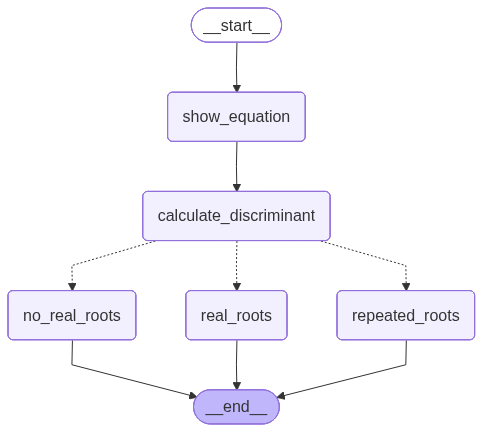

In [6]:
graph = StateGraph(QuardState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)


workflow  = graph.compile()
workflow

In [7]:
initial_state = {
    'a':6,
    'b':-9,
    'c':2
}

workflow.invoke(initial_state)

{'a': 6,
 'b': -9,
 'c': 2,
 'equation': '6x² - 9x + 2',
 'discriminant': 33,
 'result': 'The real roots are 1.228713553878169 and 0.27128644612183095'}